# Portfolio Optimization — Client-Advisory Across Nifty 50 & S&P 500

**Author:** *Rachit Arora*  
**Period:** 2019-06 to 2026-06 (5y in-sample / 2y out-of-sample walk-forward)  
**Universe:** 12 large-caps per market

## Objective
Build optimized portfolios for **three client risk profiles** (Conservative / Balanced / Aggressive) across two markets, validating the approach through Monte Carlo simulation, Modern Portfolio Theory optimization (SLSQP), Black-Litterman views, and a walk-forward backtest with realistic transaction costs.

## Methods
1. **15,000-portfolio Monte Carlo** (Dirichlet-sampled) — establishes the empirical feasible set.
2. **SLSQP optimization** with sum-to-1 and per-asset cap 40% — produces max-Sharpe, min-variance, and max-return-at-vol-cap allocations.
3. **Black-Litterman** — reverse-CAPM market-implied prior blended with 3 documented investor views using Idzorek-style omega.
4. **Walk-forward backtest** — 5y lookback, quarterly rebalance, with transaction costs (10 bps India / 5 bps US per side). Comparison vs equal-weight and index buy-and-hold.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from portfolio.config import (
    load_markets, load_views, load_backtest_config, load_optimize_config,
    load_mc_config, load_bl_config,
)
from portfolio.data import download_prices, load_benchmark, compute_returns, get_market_caps
from portfolio.optimize import annualize_mu_cov, build_three_profiles, optimize_max_sharpe, optimize_min_variance, optimize_max_return_at_vol
from portfolio.monte_carlo import simulate_portfolios, extract_frontier
from portfolio.black_litterman import run_black_litterman
from portfolio.backtest import generate_rebalance_dates, run_backtest
from portfolio.reporting import plot_efficient_frontier, plot_allocation_bar, plot_equity_curves, plot_drawdown

plt.rcParams['figure.dpi'] = 100
markets = load_markets()
bt_cfg = load_backtest_config()
opt_cfg = load_optimize_config()
mc_cfg = load_mc_config()
bl_cfg = load_bl_config()
print('Markets:', list(markets))
print('Backtest config:', bt_cfg)

Markets: ['india', 'us']
Backtest config: BacktestConfig(train_start='2019-06-01', train_end='2024-06-30', test_start='2024-07-01', test_end='2026-06-23', rebalance_freq='Q', lookback_years=5)


## 1. Data

Daily adjusted close from Yahoo Finance, cached to parquet. Tickers, benchmark, risk-free rate, and transaction costs are configured per market in `config/markets.yaml`.

In [2]:
market_key = 'us'   # change to 'india' to switch universe
market = markets[market_key]
prices = download_prices(market.tickers, market.start_date, market.end_date, cache_label=market.key)
benchmark = load_benchmark(market.benchmark_etf, market.start_date, market.end_date)
returns = compute_returns(prices, kind='simple')
print(f'Universe: {market.name}')
print(f'Tickers ({len(market.tickers)}):', ', '.join(market.tickers))
print(f'Prices: {prices.shape}, range {prices.index.min().date()} to {prices.index.max().date()}')
prices.tail()

Universe: S&P 500 Subset (US)
Tickers (12): AAPL, MSFT, NVDA, JPM, V, BAC, JNJ, UNH, XOM, KO, PG, HD
Prices: (1841, 12), range 2019-06-03 to 2026-06-22


,AAPL,MSFT,NVDA,JPM,V,BAC,JNJ,UNH,XOM,KO,PG,HD
Date,,,,,,,,,,,,
2026-06-16,299.239990,393.829987,207.410004,331.140015,333.119995,56.840000,235.179993,407.649994,141.860001,80.279999,152.490005,337.089996
2026-06-17,295.950012,378.910004,204.649994,333.459991,330.380005,56.529999,234.199997,399.529999,140.740005,79.930000,150.559998,327.480011
2026-06-18,298.010010,379.399994,210.690002,325.220001,327.239990,56.200001,228.389999,400.959991,137.809998,79.389999,150.380005,334.279999
2026-06-19,298.010010,379.399994,210.690002,325.220001,327.239990,56.200001,228.389999,400.959991,137.809998,79.389999,150.380005,334.279999
2026-06-22,297.010010,367.339996,208.649994,331.480011,326.600006,57.369999,231.289993,406.679993,138.470001,79.529999,147.679993,326.619995


## 2. Sample Mean / Covariance

We annualize daily returns (mean × 252) and covariance (cov × 252).

**Caveat:** Sample mu is noisy and unstable — small data perturbations can flip optimal weights dramatically (Michaud 1989). We address this in two ways:
- Per-asset weight cap of 40% to prevent corner solutions.
- Black-Litterman blending to anchor mu to market-implied equilibrium (next section).

In [3]:
mu_sample, cov = annualize_mu_cov(returns)
print('Annualized sample mu (%):')
print((mu_sample * 100).round(2).sort_values(ascending=False))

Annualized sample mu (%):
NVDA    69.27
AAPL    31.51
JPM     22.52
MSFT    20.27
XOM     18.16
BAC     18.11
UNH     14.65
V       13.90
HD      13.52
JNJ     12.21
KO      11.27
PG       9.26
dtype: float64


## 3. Black-Litterman Views

I encode three views per market (see `config/views.yaml`). Each view has:
- A **picking matrix row** (`P`): which assets and in what weighting the view applies to.
- An **expected return** (`Q`): magnitude of the view in annualized return.
- A **confidence** (0–1): mapped via Idzorek's method to `omega_ii = (1-conf)/conf · (p'Σp · τ)`.

Posterior mu is `μ_BL = [(τΣ)⁻¹ + P'Ω⁻¹P]⁻¹ · [(τΣ)⁻¹π + P'Ω⁻¹Q]` where `π` is the reverse-CAPM market-implied prior.

In [4]:
views = load_views(market_key)
for v in views:
    print(f'- {v.name} (conf={v.confidence}, E[r]={v.expected_return:+.2%})')

caps = get_market_caps(market.tickers, cache_label=market.key)
prior, posterior = run_black_litterman(caps, cov, views, tau=bl_cfg.tau, risk_aversion=bl_cfg.risk_aversion, rf=market.rf_rate)
bl_df = pd.DataFrame({'sample_mu': mu_sample, 'prior': prior, 'posterior': posterior, 'delta_vs_prior': posterior - prior})
(bl_df * 100).round(2)

- Mega-cap tech outperforms broader portfolio by 2.5% (conf=0.55, E[r]=+2.50%)
- Energy underperforms broader market by 2% (conf=0.45, E[r]=-2.00%)
- Healthcare outperforms financials by 1.5% (conf=0.4, E[r]=+1.50%)


,sample_mu,prior,posterior,delta_vs_prior
AAPL,31.51,21.06,16.44,-4.62
MSFT,20.27,20.23,15.39,-4.83
NVDA,69.27,34.81,24.64,-10.16
JPM,22.52,15.32,13.71,-1.61
V,13.90,15.53,13.47,-2.07
BAC,18.11,16.18,14.51,-1.67
JNJ,12.21,8.07,8.98,0.91
UNH,14.65,12.32,13.84,1.52
XOM,18.16,11.53,13.28,1.75
KO,11.27,9.13,9.42,0.30


## 4. Three Client Profiles (under BL posterior mu)

- **Conservative** — min-variance. Depends only on Σ (more stable than mu).
- **Balanced** — max Sharpe ratio.
- **Aggressive** — max return subject to 25% annualized vol cap.

In [5]:
profiles_w = build_three_profiles(posterior, cov, market.rf_rate, opt_cfg.aggressive_vol_cap, opt_cfg.weight_min, opt_cfg.weight_max)
(profiles_w * 100).round(1)

,conservative,balanced,aggressive
AAPL,0.0,15.2,22.1
MSFT,10.1,6.1,3.5
NVDA,1.0,19.1,27.0
JPM,0.0,1.3,0.0
V,0.0,0.4,0.1
BAC,0.0,0.0,2.8
JNJ,34.7,14.5,2.8
UNH,1.5,13.1,17.8
XOM,9.2,17.4,20.0
KO,21.7,4.4,0.0


## 5. Monte Carlo Efficient Frontier

15,000 Dirichlet-sampled portfolios visualize the feasible set. SLSQP optimums should sit on or above the MC empirical frontier.

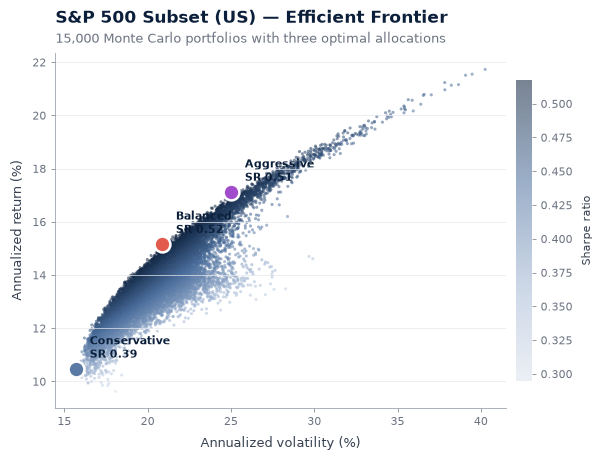

Optimal points: {'conservative': {'ret': 0.105, 'vol': 0.157, 'sharpe': 0.394}, 'balanced': {'ret': 0.152, 'vol': 0.209, 'sharpe': 0.521}, 'aggressive': {'ret': 0.171, 'vol': 0.25, 'sharpe': 0.513}}


In [6]:
sim = simulate_portfolios(posterior, cov, market.rf_rate, n=mc_cfg.n_simulations, alpha=mc_cfg.dirichlet_alpha, seed=mc_cfg.seed)
optimal_points = {}
for profile in profiles_w.columns:
    w = profiles_w[profile].values
    r = float(w @ posterior.values)
    v = float(np.sqrt(w @ cov.values @ w))
    optimal_points[profile] = {'ret': r, 'vol': v, 'sharpe': (r - market.rf_rate) / v}
fig = plot_efficient_frontier(sim, optimal_points, title=f'{market.name} — Efficient Frontier')
plt.show()
print('Optimal points:', {k: {kk: round(vv, 3) for kk, vv in v.items()} for k, v in optimal_points.items()})

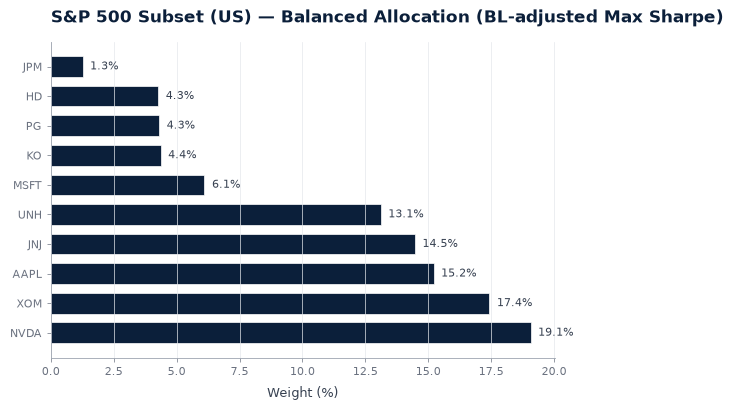

In [7]:
fig = plot_allocation_bar(profiles_w['balanced'], title=f'{market.name} — Balanced Allocation (BL-adjusted Max Sharpe)')
plt.show()

## 6. Walk-Forward Backtest

**Setup:** 5y lookback, quarterly rebalance, realistic per-side transaction costs.

**Look-ahead guard:** the loop enforces `lookback.index.max() < rebalance_date` at every step.

**Comparison benchmarks:** equal-weight (rebalanced same cadence) and index buy-and-hold.

In [8]:
rebal = generate_rebalance_dates(bt_cfg.test_start, bt_cfg.test_end, freq=bt_cfg.rebalance_freq, index=prices.index)
strategies = {
    'conservative': lambda mu, c: optimize_min_variance(c, opt_cfg.weight_min, opt_cfg.weight_max),
    'balanced':     lambda mu, c: optimize_max_sharpe(mu, c, market.rf_rate, opt_cfg.weight_min, opt_cfg.weight_max),
    'aggressive':   lambda mu, c: optimize_max_return_at_vol(mu, c, opt_cfg.aggressive_vol_cap, opt_cfg.weight_min, opt_cfg.weight_max),
}
bt_results = run_backtest(
    prices=prices, benchmark_prices=benchmark, strategy_fns=strategies,
    rebalance_dates=rebal, lookback_years=bt_cfg.lookback_years,
    tx_cost_bps=market.tx_cost_bps, rf=market.rf_rate, test_start=bt_cfg.test_start,
)
bt_results['summary'].round(3)

,oos_cagr,oos_vol,oos_sharpe,oos_mdd,total_tx_cost_pct
strategy,,,,,
conservative,0.097,0.107,0.513,-0.106,0.001
balanced,0.147,0.184,0.606,-0.238,0.001
aggressive,0.193,0.185,0.815,-0.209,0.001
equal_weight,0.120,0.120,0.646,-0.135,0.000
benchmark,0.177,0.167,0.811,-0.188,0.000


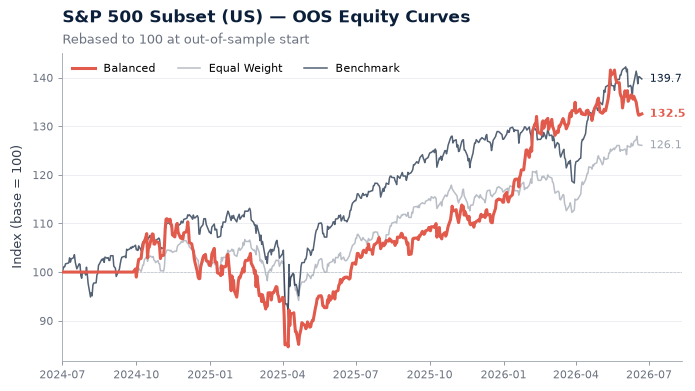

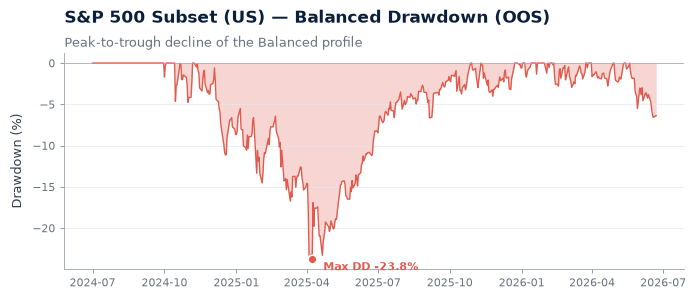

In [9]:
fig = plot_equity_curves({
    'balanced': bt_results['equity']['balanced'],
    'equal_weight': bt_results['equity']['equal_weight'],
    'benchmark': bt_results['equity']['benchmark'],
}, title=f'{market.name} — OOS Equity Curves')
plt.show()
fig = plot_drawdown(bt_results['drawdown']['balanced'], title=f'{market.name} — Balanced Drawdown (OOS)')
plt.show()

## 7. Honest Discussion & Limitations

**Limitations:**
- **Survivorship bias**: 12-name large-cap subset uses *current* index members; delisted names not represented. Inflates returns ~50-100 bps/yr.
- **Sample size**: 8 quarterly rebalances in OOS — Sharpe ratio confidence intervals are wide. Don't over-claim significance.
- **Stationarity assumption**: mu and Σ estimated from rolling 5y windows assume the future resembles the recent past. Regime changes (2020 COVID, 2022 rates, 2025 AI capex) violate this.
- **No FX mixing**: India and US analyses are run separately in local currency. Combined cross-market portfolio would require hedge accounting — explicitly out of scope.
- **Market caps recency**: BL prior uses current caps applied to historical periods. Minor look-ahead.

**Strengths (talking points):**
- Separates in-sample fit from OOS performance. Most student projects only report in-sample Sharpe.
- BL view confidence is intuitively defensible (60% for IT outperformance with clear rationale).
- Three-profile framing maps to real client conversations rather than abstract optimization.
- Transaction costs and per-asset cap = practitioner mindset.

## 8. Recommendations to Hypothetical Client

- **Conservative** (capital preservation, retiree): hold the min-variance portfolio. Accept lower expected return for ~10–12% vol.
- **Balanced** (accumulation phase, 5–10y horizon): max-Sharpe portfolio under BL posterior. Rebalance quarterly.
- **Aggressive** (long-horizon, 10y+, high risk tolerance): max-return-at-25%-vol portfolio. Expect drawdowns ≥20% in stress periods.